LOGISTICS PREDICTIVE MODELING PROJECT

Dataset successfully loaded!
Number of rows: 180519
Number of columns: 53

Cleaned column names:
['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_email', 'customer_fname', 'customer_id', 'customer_lname', 'customer_password', 'customer_segment', 'customer_state', 'customer_street', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date_dateorders', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'order_zipcode', 'product_card_id', 'product

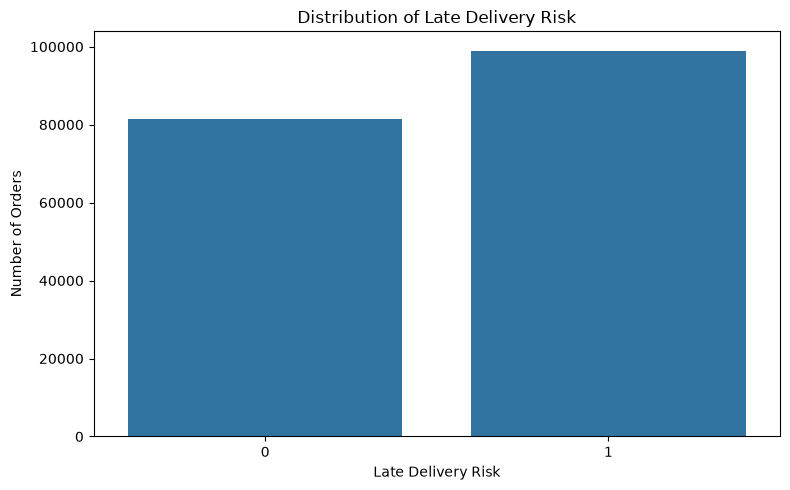


SELECTED FEATURES
- days_for_shipping_real
- days_for_shipment_scheduled
- shipping_mode
- benefit_per_order
- sales_per_customer
- order_item_discount
- order_item_discount_rate
- order_item_product_price
- order_item_profit_ratio
- sales
- order_item_total
- order_profit_per_order
- product_price
- order_item_quantity
- market
- order_region
- category_name
- customer_segment

Rows available for modeling: 180519

Feature matrix shape: (180519, 18)
Target shape: (180519,)

Numerical features:
['days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'order_item_discount', 'order_item_discount_rate', 'order_item_product_price', 'order_item_profit_ratio', 'sales', 'order_item_total', 'order_profit_per_order', 'product_price', 'order_item_quantity']

Categorical features:
['shipping_mode', 'market', 'order_region', 'category_name', 'customer_segment']

TRAIN TEST SPLIT
Training samples: 144415
Testing samples: 36104

TRAINING LOGISTIC REGRESSIO

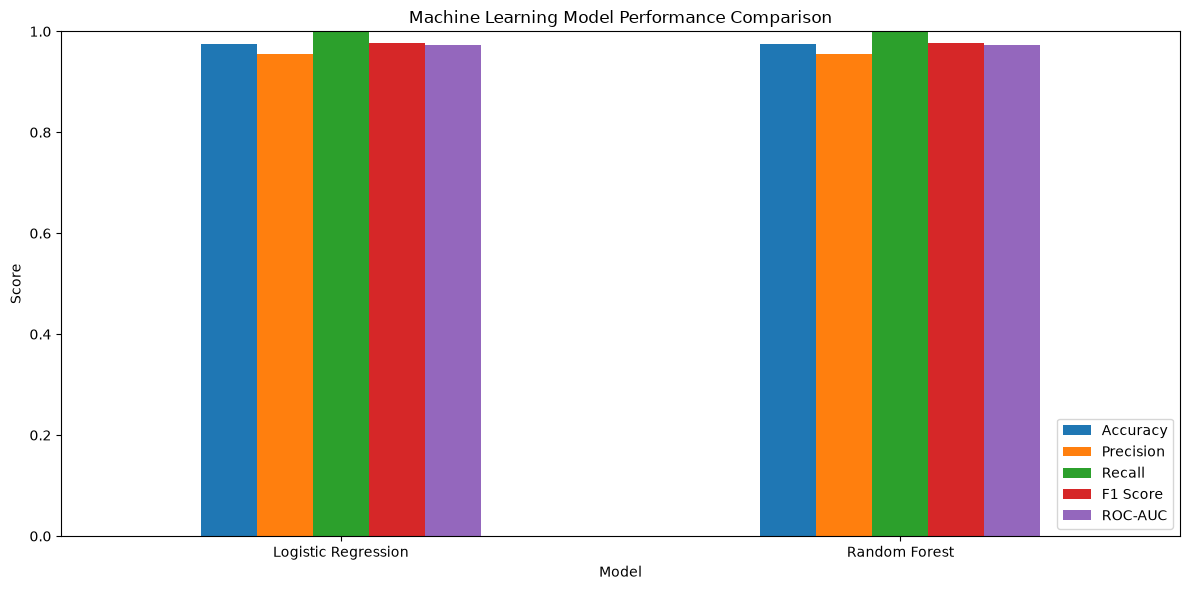


RANDOM FOREST CONFUSION MATRIX
[[15386   922]
 [    0 19796]]


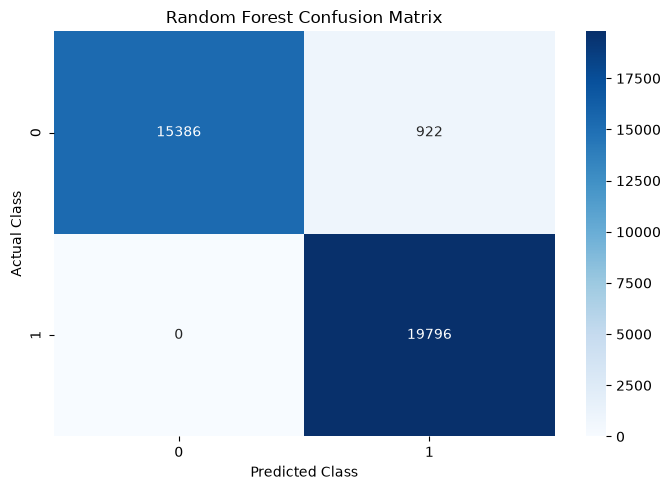

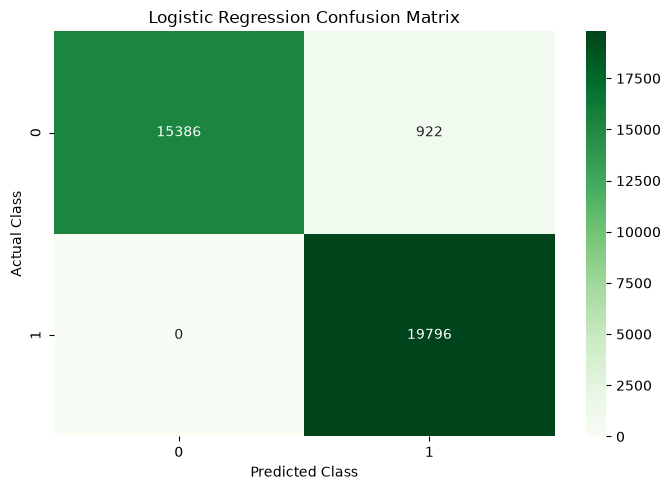

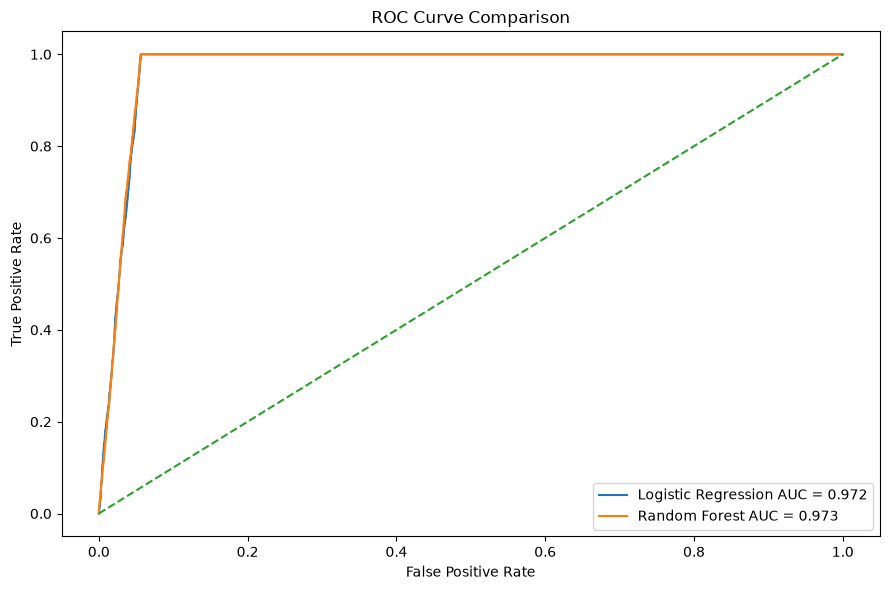


TOP 20 IMPORTANT FEATURES
                                      Feature  Importance
0           numerical__days_for_shipping_real    0.595764
1      numerical__days_for_shipment_scheduled    0.121214
13     categorical__shipping_mode_First Class    0.102908
16  categorical__shipping_mode_Standard Class    0.100092
15    categorical__shipping_mode_Second Class    0.040466
14        categorical__shipping_mode_Same Day    0.007368
10          numerical__order_profit_per_order    0.003702
2                numerical__benefit_per_order    0.003492
7          numerical__order_item_profit_ratio    0.002855
9                 numerical__order_item_total    0.002636
3               numerical__sales_per_customer    0.002551
4              numerical__order_item_discount    0.002514
5         numerical__order_item_discount_rate    0.001849
8                            numerical__sales    0.001318
6         numerical__order_item_product_price    0.001012
11                   numerical__product_price

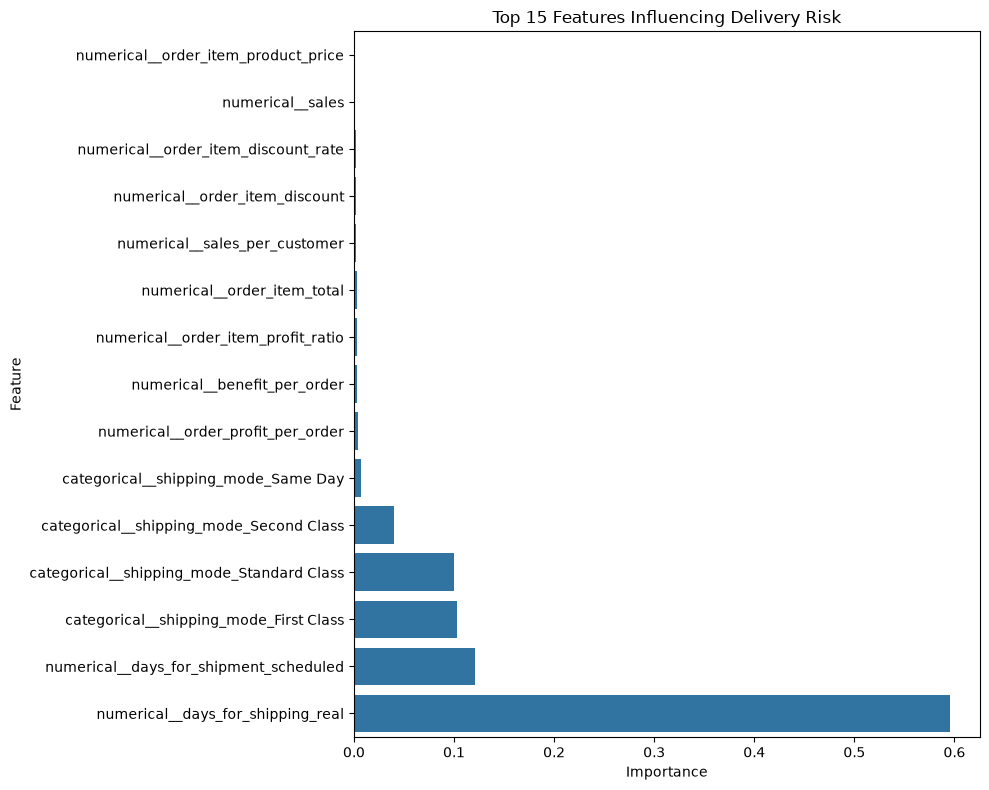


CROSS VALIDATION

Random Forest 5-Fold F1 Scores:
[0.98799631 0.97915069 0.92419909 0.96575109 0.9670579 ]

Average Cross Validation F1 Score: 0.9648
Standard Deviation: 0.0219

GENERATING DELIVERY RISK PREDICTIONS

Risk Category Distribution:
risk_category
Critical    96606
Low         74491
High         6759
Medium       2663
Name: count, dtype: int64


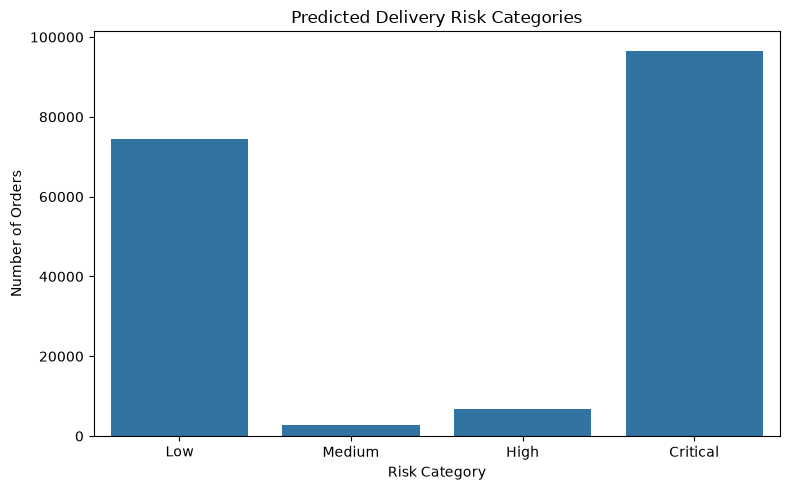


Predictions saved successfully.

LOGISTICS OPTIMIZATION ANALYSIS

Average predicted risk by shipping mode:
shipping_mode
First Class       0.935912
Second Class      0.763021
Same Day          0.459663
Standard Class    0.386389
Name: predicted_late_probability, dtype: float64


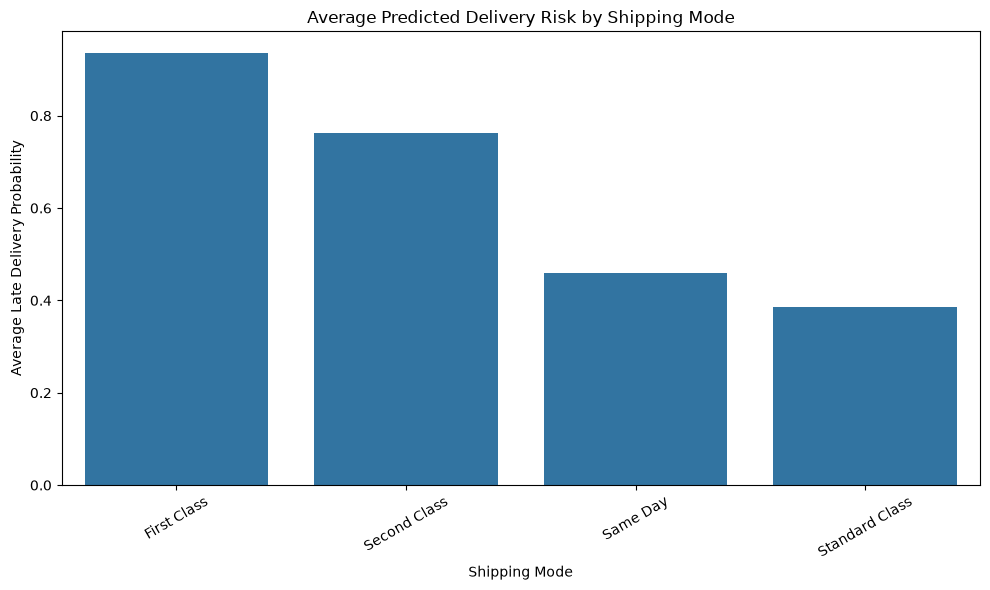


Average predicted risk by market:
market
Europe          0.552669
Pacific Asia    0.550208
USCA            0.547498
LATAM           0.544607
Africa          0.543677
Name: predicted_late_probability, dtype: float64


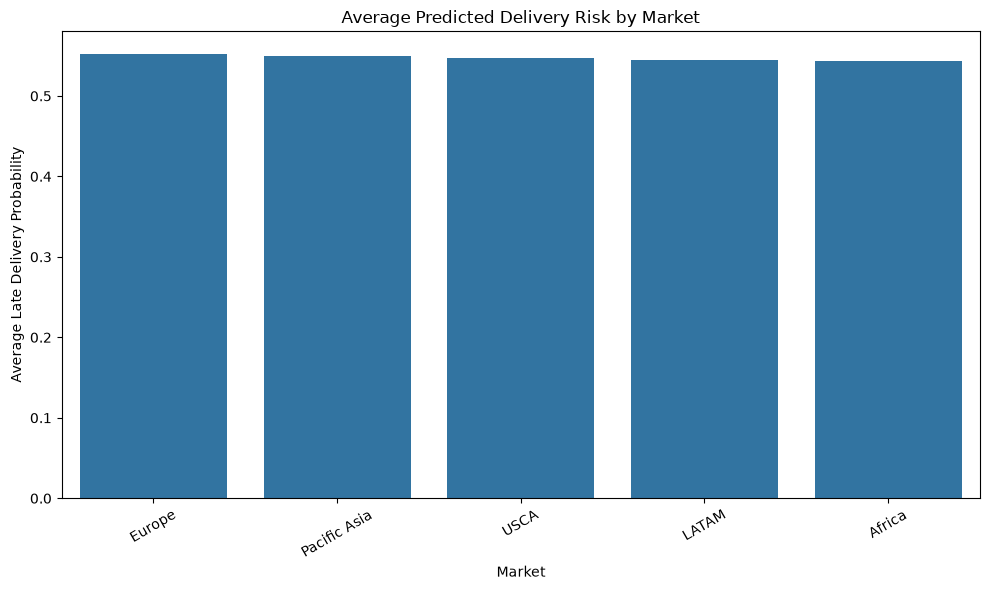


Number of High/Critical Risk Shipments: 103365
Percentage of High/Critical Risk Shipments: 57.26 %

OPTIMIZATION RECOMMENDATIONS
1. Prioritize shipments with predicted late-delivery probability above 80%.
2. Monitor shipments with risk between 60% and 80% and allocate additional logistics resources where necessary.
3. Use lower-risk shipping modes for time-sensitive shipments whenever operationally and financially feasible.
4. Investigate markets and regions with consistently high predicted delivery risk.
5. Use historical demand and risk predictions to improve vehicle and workforce allocation.
6. Continuously retrain the predictive model as new shipment data becomes available.

FINAL PROJECT SUMMARY
                          Metric          Value
0                     Best Model  Random Forest
1                  Best F1 Score         0.9772
2                   Best ROC-AUC         0.9726
3   High/Critical Risk Shipments         103365
4  High/Critical Risk Percentage          57.26
5

In [1]:
# ==============================================================
# WEEK 4 TASK
# PREDICTIVE MODELING AND OPTIMIZATION IN LOGISTICS
#
# Dataset:
# DataCo Smart Supply Chain Dataset
#
# Objective:
# Predict Late Delivery Risk and provide logistics
# optimization recommendations.
# ==============================================================


# ==============================================================
# 1. IMPORT LIBRARIES
# ==============================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


warnings.filterwarnings("ignore")


# ==============================================================
# 2. CREATE OUTPUT DIRECTORY
# ==============================================================

OUTPUT_DIR = "outputs"

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print("=" * 70)
print("LOGISTICS PREDICTIVE MODELING PROJECT")
print("=" * 70)


# ==============================================================
# 3. LOAD DATASET
# ==============================================================

FILE_PATH = "DataCoSupplyChainDataset.csv"

try:

    df = pd.read_csv(
        FILE_PATH,
        encoding="latin1"
    )

except FileNotFoundError:

    print("\nERROR:")
    print(
        "DataCoSupplyChainDataset.csv was not found."
    )

    print(
        "\nPlace the CSV file in the same folder "
        "as this Python script."
    )

    exit()


print("\nDataset successfully loaded!")

print(
    "Number of rows:",
    df.shape[0]
)

print(
    "Number of columns:",
    df.shape[1]
)


# ==============================================================
# 4. CLEAN COLUMN NAMES
# ==============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", "_")
)


print("\nCleaned column names:")
print(df.columns.tolist())


# ==============================================================
# 5. DISPLAY BASIC INFORMATION
# ==============================================================

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(
    df.isnull().sum()
    .sort_values(
        ascending=False
    )
    .head(20)
)


# ==============================================================
# 6. CHECK TARGET VARIABLE
# ==============================================================

TARGET = "late_delivery_risk"

if TARGET not in df.columns:

    print(
        "\nERROR: Target variable "
        "'late_delivery_risk' was not found."
    )

    print(
        "\nAvailable columns:"
    )

    print(df.columns.tolist())

    exit()


print("\nTarget variable found:", TARGET)


# ==============================================================
# 7. TARGET DISTRIBUTION
# ==============================================================

print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print("=" * 70)

print(
    df[TARGET].value_counts()
)

print("\nTarget percentages:")

print(
    df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ==============================================================
# 8. TARGET DISTRIBUTION VISUALIZATION
# ==============================================================

plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    data=df,
    x=TARGET
)

plt.title(
    "Distribution of Late Delivery Risk"
)

plt.xlabel(
    "Late Delivery Risk"
)

plt.ylabel(
    "Number of Orders"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "01_target_distribution.png"
    ),
    dpi=300
)

plt.show()


# ==============================================================
# 9. SELECT FEATURES
# ==============================================================

possible_features = [

    # Shipping information
    "days_for_shipping_real",
    "days_for_shipment_scheduled",
    "shipping_mode",

    # Financial information
    "benefit_per_order",
    "sales_per_customer",
    "order_item_discount",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_profit_ratio",
    "sales",
    "order_item_total",
    "order_profit_per_order",
    "product_price",

    # Order information
    "order_item_quantity",

    # Geography
    "market",
    "order_region",

    # Product information
    "category_name",

    # Customer information
    "customer_segment"
]


# Keep only columns that actually exist
FEATURES = [
    column
    for column in possible_features
    if column in df.columns
]


print("\n" + "=" * 70)
print("SELECTED FEATURES")
print("=" * 70)

for feature in FEATURES:
    print("-", feature)


# ==============================================================
# 10. CREATE MODEL DATASET
# ==============================================================

model_df = df[
    FEATURES + [TARGET]
].copy()


# Remove rows with missing target
model_df = model_df.dropna(
    subset=[TARGET]
)


print(
    "\nRows available for modeling:",
    len(model_df)
)


# ==============================================================
# 11. SEPARATE FEATURES AND TARGET
# ==============================================================

X = model_df[FEATURES]

y = model_df[TARGET]


print(
    "\nFeature matrix shape:",
    X.shape
)

print(
    "Target shape:",
    y.shape
)


# ==============================================================
# 12. IDENTIFY NUMERICAL FEATURES
# ==============================================================

numerical_features = (
    X.select_dtypes(
        include=[
            "int64",
            "float64",
            "int32",
            "float32"
        ]
    )
    .columns
    .tolist()
)


# ==============================================================
# 13. IDENTIFY CATEGORICAL FEATURES
# ==============================================================

categorical_features = (
    X.select_dtypes(
        include=["object"]
    )
    .columns
    .tolist()
)


print(
    "\nNumerical features:"
)

print(
    numerical_features
)


print(
    "\nCategorical features:"
)

print(
    categorical_features
)


# ==============================================================
# 14. NUMERICAL PREPROCESSING
# ==============================================================

numerical_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ==============================================================
# 15. CATEGORICAL PREPROCESSING
# ==============================================================

categorical_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ==============================================================
# 16. COMBINE PREPROCESSING
# ==============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ==============================================================
# 17. TRAIN-TEST SPLIT
# ==============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\n" + "=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)


# ==============================================================
# 18. LOGISTIC REGRESSION MODEL
# ==============================================================

logistic_model = Pipeline(
    steps=[

        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)


print("\n" + "=" * 70)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 70)


logistic_model.fit(
    X_train,
    y_train
)


# Make predictions
logistic_prediction = (
    logistic_model.predict(
        X_test
    )
)


# Prediction probability
logistic_probability = (
    logistic_model
    .predict_proba(
        X_test
    )[:, 1]
)


# ==============================================================
# 19. LOGISTIC REGRESSION EVALUATION
# ==============================================================

logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

logistic_precision = precision_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_prediction,
    zero_division=0
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probability
)


print("\nLOGISTIC REGRESSION RESULTS")

print(
    "Accuracy :",
    round(logistic_accuracy, 4)
)

print(
    "Precision:",
    round(logistic_precision, 4)
)

print(
    "Recall   :",
    round(logistic_recall, 4)
)

print(
    "F1 Score :",
    round(logistic_f1, 4)
)

print(
    "ROC-AUC  :",
    round(logistic_auc, 4)
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        logistic_prediction,
        zero_division=0
    )
)


# ==============================================================
# 20. RANDOM FOREST MODEL
# ==============================================================

random_forest_model = Pipeline(
    steps=[

        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            RandomForestClassifier(

                n_estimators=100,

                max_depth=15,

                min_samples_split=5,

                random_state=42,

                n_jobs=-1
            )
        )
    ]
)


print("\n" + "=" * 70)
print("TRAINING RANDOM FOREST")
print("=" * 70)


random_forest_model.fit(
    X_train,
    y_train
)


# Make predictions
rf_prediction = (
    random_forest_model.predict(
        X_test
    )
)


# Prediction probabilities
rf_probability = (
    random_forest_model
    .predict_proba(
        X_test
    )[:, 1]
)


# ==============================================================
# 21. RANDOM FOREST EVALUATION
# ==============================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

rf_precision = precision_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_prediction,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_probability
)


print("\nRANDOM FOREST RESULTS")

print(
    "Accuracy :",
    round(rf_accuracy, 4)
)

print(
    "Precision:",
    round(rf_precision, 4)
)

print(
    "Recall   :",
    round(rf_recall, 4)
)

print(
    "F1 Score :",
    round(rf_f1, 4)
)

print(
    "ROC-AUC  :",
    round(rf_auc, 4)
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_prediction,
        zero_division=0
    )
)


# ==============================================================
# 22. MODEL COMPARISON
# ==============================================================

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],

    "Precision": [
        logistic_precision,
        rf_precision
    ],

    "Recall": [
        logistic_recall,
        rf_recall
    ],

    "F1 Score": [
        logistic_f1,
        rf_f1
    ],

    "ROC-AUC": [
        logistic_auc,
        rf_auc
    ]
})


print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    comparison.round(4)
)


# Save comparison
comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_comparison.csv"
    ),
    index=False
)


# ==============================================================
# 23. MODEL COMPARISON GRAPH
# ==============================================================

comparison_plot = comparison.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]


comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Machine Learning Model Performance Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.xticks(
    rotation=0
)

plt.ylim(
    0,
    1
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "02_model_comparison.png"
    ),
    dpi=300
)

plt.show()


# ==============================================================
# 24. CONFUSION MATRIX - RANDOM FOREST
# ==============================================================

rf_cm = confusion_matrix(
    y_test,
    rf_prediction
)


print("\n" + "=" * 70)
print("RANDOM FOREST CONFUSION MATRIX")
print("=" * 70)

print(
    rf_cm
)


plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "03_random_forest_confusion_matrix.png"
    ),
    dpi=300
)

plt.show()


# ==============================================================
# 25. CONFUSION MATRIX - LOGISTIC REGRESSION
# ==============================================================

logistic_cm = confusion_matrix(
    y_test,
    logistic_prediction
)


plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "04_logistic_confusion_matrix.png"
    ),
    dpi=300
)

plt.show()


# ==============================================================
# 26. ROC CURVE
# ==============================================================

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probability
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probability
)


plt.figure(
    figsize=(9, 6)
)

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression AUC = {logistic_auc:.3f}"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC = {rf_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "ROC Curve Comparison"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "05_roc_curve.png"
    ),
    dpi=300
)

plt.show()


# ==============================================================
# 27. RANDOM FOREST FEATURE IMPORTANCE
# ==============================================================

rf_model = (
    random_forest_model
    .named_steps["model"]
)


fitted_preprocessor = (
    random_forest_model
    .named_steps["preprocessing"]
)


feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


importance_values = (
    rf_model.feature_importances_
)


feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance_values
})


feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)


print("\n" + "=" * 70)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 70)

print(
    feature_importance.head(20)
)


# Save feature importance
feature_importance.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "feature_importance.csv"
    ),
    index=False
)


# ==============================================================
# 28. FEATURE IMPORTANCE GRAPH
# ==============================================================

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        by="Importance"
    )
)


plt.figure(
    figsize=(10, 8)
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features Influencing Delivery Risk"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "06_feature_importance.png"
    ),
    dpi=300
)

plt.show()


# ==============================================================
# 29. CROSS VALIDATION
# ==============================================================

print("\n" + "=" * 70)
print("CROSS VALIDATION")
print("=" * 70)


cv_scores = cross_val_score(

    random_forest_model,

    X,

    y,

    cv=5,

    scoring="f1",

    n_jobs=-1
)


print(
    "\nRandom Forest 5-Fold F1 Scores:"
)

print(
    cv_scores
)


print(
    "\nAverage Cross Validation F1 Score:",
    round(
        cv_scores.mean(),
        4
    )
)


print(
    "Standard Deviation:",
    round(
        cv_scores.std(),
        4
    )
)


# ==============================================================
# 30. PREDICT RISK FOR ALL ORDERS
# ==============================================================

print("\n" + "=" * 70)
print("GENERATING DELIVERY RISK PREDICTIONS")
print("=" * 70)


all_probabilities = (
    random_forest_model
    .predict_proba(X)[:, 1]
)


model_df[
    "predicted_late_probability"
] = all_probabilities


# ==============================================================
# 31. CREATE RISK CATEGORY
# ==============================================================

def classify_risk(probability):

    if probability >= 0.80:

        return "Critical"

    elif probability >= 0.60:

        return "High"

    elif probability >= 0.30:

        return "Medium"

    else:

        return "Low"


model_df[
    "risk_category"
] = (
    model_df[
        "predicted_late_probability"
    ]
    .apply(classify_risk)
)


# ==============================================================
# 32. DISPLAY RISK DISTRIBUTION
# ==============================================================

risk_distribution = (
    model_df[
        "risk_category"
    ]
    .value_counts()
)


print(
    "\nRisk Category Distribution:"
)

print(
    risk_distribution
)


# ==============================================================
# 33. RISK DISTRIBUTION GRAPH
# ==============================================================

plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    data=model_df,
    x="risk_category",
    order=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

plt.title(
    "Predicted Delivery Risk Categories"
)

plt.xlabel(
    "Risk Category"
)

plt.ylabel(
    "Number of Orders"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "07_risk_distribution.png"
    ),
    dpi=300
)

plt.show()


# ==============================================================
# 34. SAVE PREDICTIONS
# ==============================================================

prediction_columns = [
    "predicted_late_probability",
    "risk_category"
]


# Add useful original columns if available
for column in [

    "shipping_mode",
    "market",
    "order_region",
    "sales",
    "order_item_quantity"

]:

    if column in model_df.columns:

        prediction_columns.append(
            column
        )


prediction_output = model_df[
    prediction_columns
].copy()


prediction_output.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "delivery_risk_predictions.csv"
    ),
    index=False
)


print(
    "\nPredictions saved successfully."
)


# ==============================================================
# 35. LOGISTICS OPTIMIZATION ANALYSIS
# ==============================================================

print("\n" + "=" * 70)
print("LOGISTICS OPTIMIZATION ANALYSIS")
print("=" * 70)


# --------------------------------------------------------------
# 35.1 RISK BY SHIPPING MODE
# --------------------------------------------------------------

if "shipping_mode" in model_df.columns:

    shipping_risk = (

        model_df
        .groupby("shipping_mode")
        ["predicted_late_probability"]
        .mean()
        .sort_values(
            ascending=False
        )
    )

    print(
        "\nAverage predicted risk by shipping mode:"
    )

    print(
        shipping_risk
    )


    plt.figure(
        figsize=(10, 6)
    )

    sns.barplot(
        x=shipping_risk.index,
        y=shipping_risk.values
    )

    plt.title(
        "Average Predicted Delivery Risk by Shipping Mode"
    )

    plt.xlabel(
        "Shipping Mode"
    )

    plt.ylabel(
        "Average Late Delivery Probability"
    )

    plt.xticks(
        rotation=30
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "08_shipping_mode_risk.png"
        ),
        dpi=300
    )

    plt.show()


# --------------------------------------------------------------
# 35.2 RISK BY MARKET
# --------------------------------------------------------------

if "market" in model_df.columns:

    market_risk = (

        model_df
        .groupby("market")
        ["predicted_late_probability"]
        .mean()
        .sort_values(
            ascending=False
        )
    )

    print(
        "\nAverage predicted risk by market:"
    )

    print(
        market_risk
    )


    plt.figure(
        figsize=(10, 6)
    )

    sns.barplot(
        x=market_risk.index,
        y=market_risk.values
    )

    plt.title(
        "Average Predicted Delivery Risk by Market"
    )

    plt.xlabel(
        "Market"
    )

    plt.ylabel(
        "Average Late Delivery Probability"
    )

    plt.xticks(
        rotation=30
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "09_market_risk.png"
        ),
        dpi=300
    )

    plt.show()


# ==============================================================
# 36. HIGH-RISK SHIPMENT ANALYSIS
# ==============================================================

high_risk_shipments = model_df[
    model_df[
        "predicted_late_probability"
    ] >= 0.60
].copy()


print(
    "\nNumber of High/Critical Risk Shipments:",
    len(high_risk_shipments)
)


print(
    "Percentage of High/Critical Risk Shipments:",
    round(
        len(high_risk_shipments)
        /
        len(model_df)
        *
        100,
        2
    ),
    "%"
)


# Save high-risk shipments
high_risk_shipments.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "high_risk_shipments.csv"
    ),
    index=False
)


# ==============================================================
# 37. OPTIMIZATION RECOMMENDATIONS
# ==============================================================

print("\n" + "=" * 70)
print("OPTIMIZATION RECOMMENDATIONS")
print("=" * 70)


recommendations = []


# Recommendation 1
recommendations.append(
    "Prioritize shipments with predicted "
    "late-delivery probability above 80%."
)


# Recommendation 2
recommendations.append(
    "Monitor shipments with risk between "
    "60% and 80% and allocate additional "
    "logistics resources where necessary."
)


# Recommendation 3
recommendations.append(
    "Use lower-risk shipping modes for "
    "time-sensitive shipments whenever "
    "operationally and financially feasible."
)


# Recommendation 4
recommendations.append(
    "Investigate markets and regions with "
    "consistently high predicted delivery risk."
)


# Recommendation 5
recommendations.append(
    "Use historical demand and risk predictions "
    "to improve vehicle and workforce allocation."
)


# Recommendation 6
recommendations.append(
    "Continuously retrain the predictive model "
    "as new shipment data becomes available."
)


for i, recommendation in enumerate(
    recommendations,
    start=1
):

    print(
        f"{i}. {recommendation}"
    )


# ==============================================================
# 38. CREATE OPTIMIZATION REPORT
# ==============================================================

optimization_report = pd.DataFrame({

    "Recommendation": recommendations

})


optimization_report.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "optimization_recommendations.csv"
    ),
    index=False
)


# ==============================================================
# 39. GENERATE FINAL SUMMARY
# ==============================================================

best_model = (
    "Random Forest"
    if rf_f1 >= logistic_f1
    else "Logistic Regression"
)


best_f1 = max(
    rf_f1,
    logistic_f1
)


best_auc = max(
    rf_auc,
    logistic_auc
)


summary = pd.DataFrame({

    "Metric": [

        "Best Model",

        "Best F1 Score",

        "Best ROC-AUC",

        "High/Critical Risk Shipments",

        "High/Critical Risk Percentage",

        "Cross Validation F1"
    ],

    "Value": [

        best_model,

        round(
            best_f1,
            4
        ),

        round(
            best_auc,
            4
        ),

        len(
            high_risk_shipments
        ),

        round(
            len(high_risk_shipments)
            /
            len(model_df)
            *
            100,
            2
        ),

        round(
            cv_scores.mean(),
            4
        )
    ]

})


print("\n" + "=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print(
    summary
)


summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_summary.csv"
    ),
    index=False
)


# ==============================================================
# 40. SAVE SAMPLE PREDICTIONS
# ==============================================================

print("\nSample predictions:")

print(
    prediction_output.head(10)
)


# ==============================================================
# 41. FINAL MESSAGE
# ==============================================================

print("\n" + "=" * 70)
print("WEEK 4 PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "\nBest Model:",
    best_model
)

print(
    "Best F1 Score:",
    round(
        best_f1,
        4
    )
)

print(
    "Best ROC-AUC:",
    round(
        best_auc,
        4
    )
)

print(
    "\nAll graphs and analysis files "
    "have been saved inside the 'outputs' folder."
)

print(
    "\nGenerated files:"
)

print(
    """
1. 01_target_distribution.png
2. 02_model_comparison.png
3. 03_random_forest_confusion_matrix.png
4. 04_logistic_confusion_matrix.png
5. 05_roc_curve.png
6. 06_feature_importance.png
7. 07_risk_distribution.png
8. 08_shipping_mode_risk.png
9. 09_market_risk.png
10. model_comparison.csv
11. feature_importance.csv
12. delivery_risk_predictions.csv
13. high_risk_shipments.csv
14. optimization_recommendations.csv
15. final_summary.csv
"""
)

print("=" * 70)